# Titanic: look at the data before training
Run each code cell in order with Shift+Enter. The notebook lives in notebooks/; data/train.csv lives one folder above. Nothing here fits preprocessing to the final test set.

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
df = pd.read_csv(ROOT / 'data' / 'train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print('Rows, columns:', df.shape)
print('Columns:', ', '.join(df.columns))
df.info()

Rows, columns: (891, 12)
Columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [3]:
df.isna().sum().to_frame('Missing values')

,Missing values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df['Survived'].value_counts().sort_index().to_frame('Passengers')

,Passengers
Survived,
0,549
1,342


In [5]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']
display(X.head())
display(y.head().to_frame('Target: Survived'))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


,Target: Survived
0,0
1,1
2,1
3,1
4,0


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Training:', X_train.shape, 'Final test:', X_test.shape)
print('Training survival rate:', round(y_train.mean(), 4))
print('Final test survival rate:', round(y_test.mean(), 4))
print('Disjoint row indexes:', set(X_train.index).isdisjoint(X_test.index))

Training: (712, 7) Final test: (179, 7)
Training survival rate: 0.3834
Final test survival rate: 0.3855
Disjoint row indexes: True


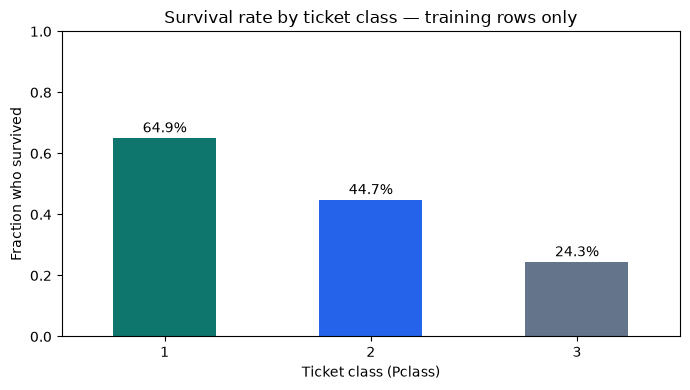

In [7]:
import matplotlib.pyplot as plt

training = X_train.assign(Survived=y_train)
rates = training.groupby('Pclass')['Survived'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
rates.plot.bar(ax=ax, color=['#0f766e', '#2563eb', '#64748b'], rot=0)
ax.set(title='Survival rate by ticket class — training rows only',
       xlabel='Ticket class (Pclass)', ylabel='Fraction who survived', ylim=(0, 1))
for position, value in enumerate(rates):
    ax.text(position, value + 0.02, f'{value:.1%}', ha='center')
fig.tight_layout()
(ROOT / 'outputs').mkdir(exist_ok=True)
fig.savefig(ROOT / 'outputs' / 'training_class_rates.png', dpi=150)
plt.show()

The class chart describes association, not proof that buying a different ticket would change an individual's fate. The final test rows remain aside. Next, build src/train_model.py; it will repeat the same split, learn preprocessing separately inside each cross-validation fold, compare five models, and evaluate just the chosen final pipeline.